<a href="https://colab.research.google.com/github/dev-pranshu04/Stability-Prediction-of-Gold-Silver-Nanoclusters/blob/main/Stability_Prediction_of_Au%E2%80%93Ag_Nanoclusters_Using_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

# System Utilities
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set Global Visualization Parameters
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

In [ ]:
# Upload Dataset
from google.colab import files
import io


print("DATA UPLOAD AND INITIAL INSPECTION")


uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nDataset: {filename}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Display Initial Information
print("\n" + "-"*40)
print("DATASET OVERVIEW")
print("-"*40)
print(df.info())

print("\n" + "-"*40)
print("STATISTICAL SUMMARY")
print("-"*40)
display(df.describe())

DATA UPLOAD AND INITIAL INSPECTION


Saving au_ag_nanocluster_stability_dataset_with_dft_labels.csv to au_ag_nanocluster_stability_dataset_with_dft_labels.csv

Dataset: au_ag_nanocluster_stability_dataset_with_dft_labels.csv
Shape: (1000, 10)
Columns: ['cluster_size', 'au_atoms', 'ag_atoms', 'au_ag_ratio', 'avg_binding_energy_ev', 'coordination_number', 'surface_energy_ev', 'stability_score', 'homo_lumo_gap_ev', 'formation_energy_ev']

----------------------------------------
DATASET OVERVIEW
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cluster_size           1000 non-null   int64  
 1   au_atoms               1000 non-null   int64  
 2   ag_atoms               1000 non-null   int64  
 3   au_ag_ratio            1000 non-null   float64
 4   avg_binding_energy_ev  1000 non-null   float64
 5   coordination_number    

,cluster_size,au_atoms,ag_atoms,au_ag_ratio,avg_binding_energy_ev,coordination_number,surface_energy_ev,stability_score,homo_lumo_gap_ev,formation_energy_ev
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,51.421000,49.059000,47.291000,0.498850,-3.013446,7.920219,1.496167,3.521854,1.987723,123.970540
std,27.960249,29.197912,29.247765,0.289928,0.860646,2.295313,0.575923,0.822490,0.291726,77.354696
min,5.000000,0.000000,0.000000,0.000012,-4.498040,4.000246,0.501887,1.477023,1.215873,3.984380
25%,27.000000,24.000000,21.000000,0.259814,-3.757997,5.926164,0.998760,2.879958,1.764069,58.136660
50%,52.000000,48.000000,45.500000,0.496578,-3.028920,7.868387,1.477686,3.483971,1.985356,112.728269
75%,74.000000,74.000000,73.000000,0.754752,-2.280868,9.903469,1.972290,4.147630,2.234558,180.132247
max,99.000000,99.000000,99.000000,0.997821,-1.501327,11.981995,2.498701,5.527896,2.825273,353.313507


EXPLORATORY DATA ANALYSIS


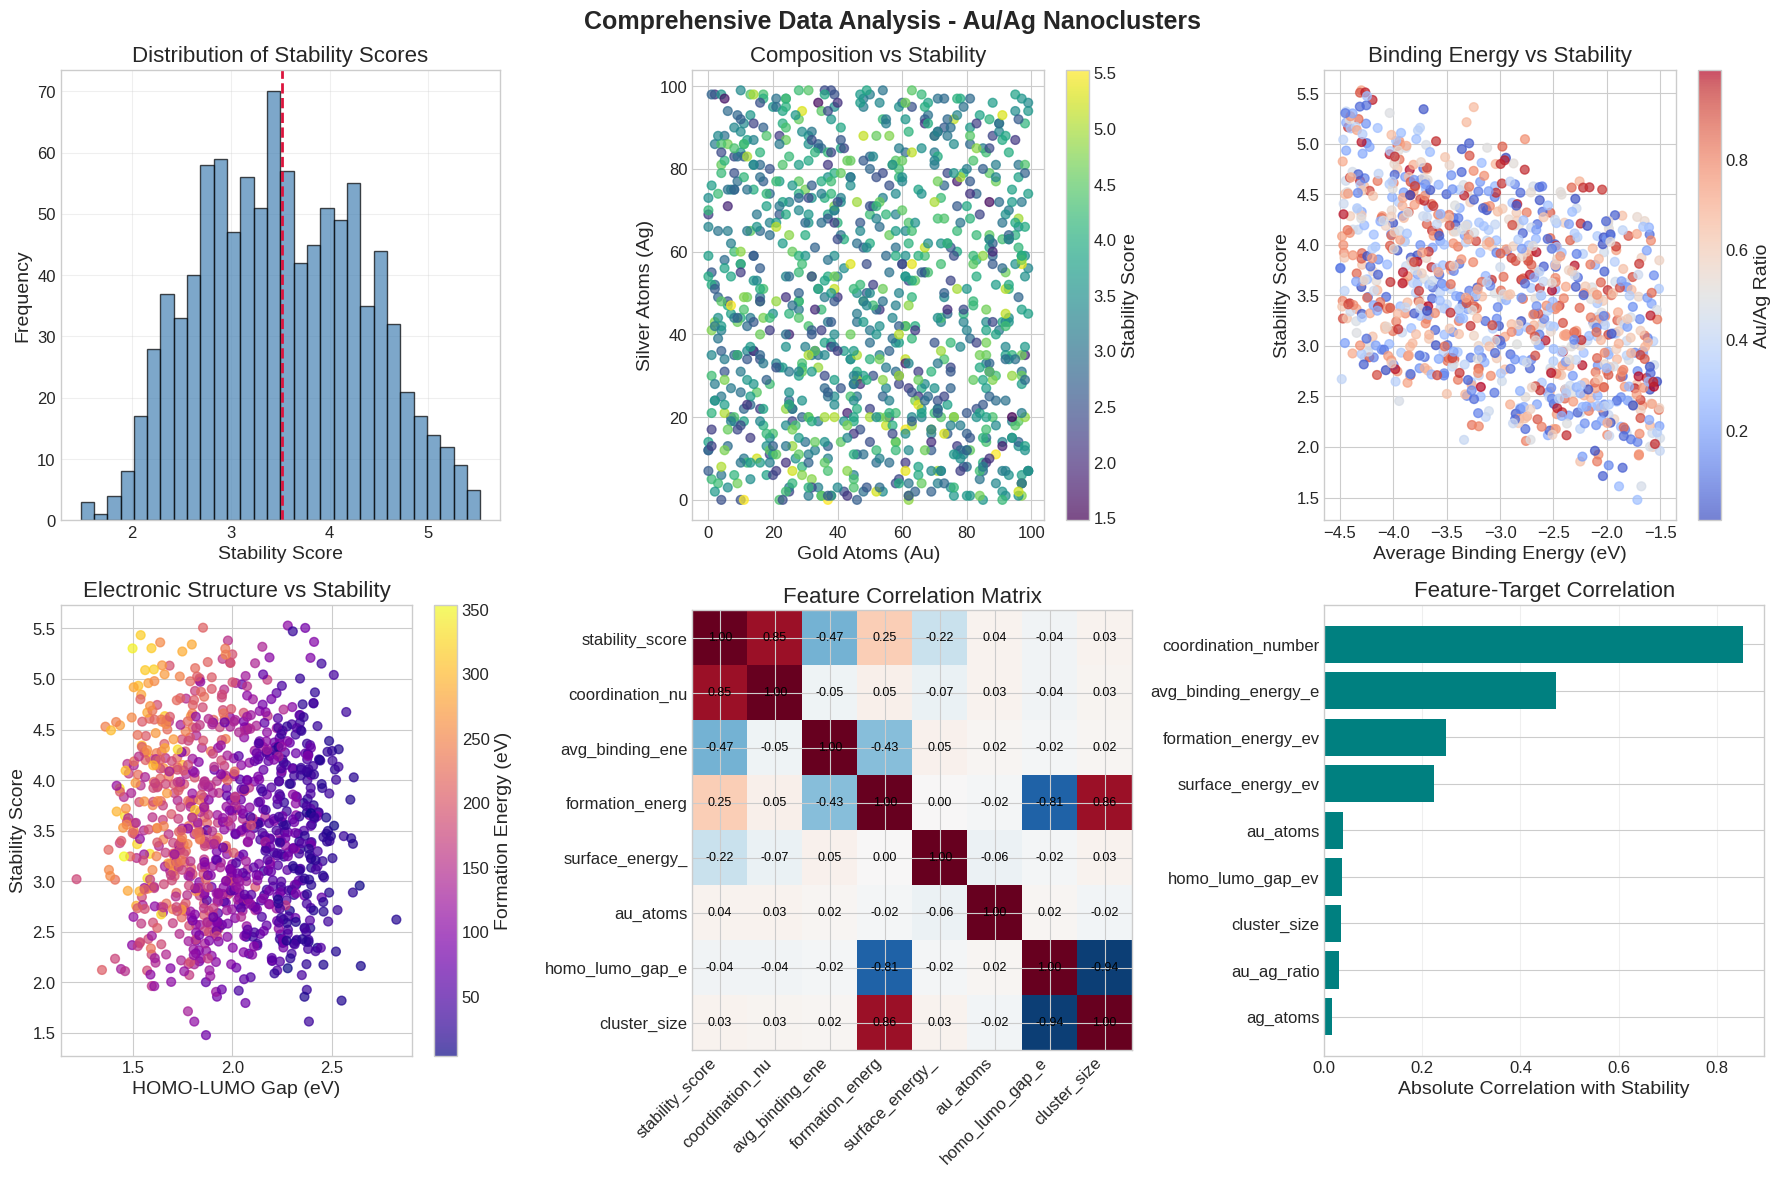

In [ ]:

print("EXPLORATORY DATA ANALYSIS")


# Create Multi-panel Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Panel 1: Target Variable Distribution
axes[0,0].hist(df['stability_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['stability_score'].mean(), color='crimson', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Stability Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Stability Scores')
axes[0,0].grid(True, alpha=0.3)

# Panel 2: Composition Analysis
scatter1 = axes[0,1].scatter(df['au_atoms'], df['ag_atoms'],
                            c=df['stability_score'],
                            cmap='viridis',
                            s=40,
                            alpha=0.7)
axes[0,1].set_xlabel('Gold Atoms (Au)')
axes[0,1].set_ylabel('Silver Atoms (Ag)')
axes[0,1].set_title('Composition vs Stability')
plt.colorbar(scatter1, ax=axes[0,1], label='Stability Score')

# Panel 3: Binding Energy Analysis
scatter2 = axes[0,2].scatter(df['avg_binding_energy_ev'], df['stability_score'],
                            c=df['au_ag_ratio'],
                            cmap='coolwarm',
                            s=40,
                            alpha=0.7)
axes[0,2].set_xlabel('Average Binding Energy (eV)')
axes[0,2].set_ylabel('Stability Score')
axes[0,2].set_title('Binding Energy vs Stability')
plt.colorbar(scatter2, ax=axes[0,2], label='Au/Ag Ratio')

# Panel 4: Electronic Structure Analysis
axes[1,0].scatter(df['homo_lumo_gap_ev'], df['stability_score'],
                  c=df['formation_energy_ev'],
                  cmap='plasma',
                  s=40,
                  alpha=0.7)
axes[1,0].set_xlabel('HOMO-LUMO Gap (eV)')
axes[1,0].set_ylabel('Stability Score')
axes[1,0].set_title('Electronic Structure vs Stability')
plt.colorbar(axes[1,0].collections[0], ax=axes[1,0], label='Formation Energy (eV)')

# Panel 5: Correlation Matrix
corr_matrix = df.corr()
top_features = corr_matrix['stability_score'].abs().sort_values(ascending=False).index[:8]
top_corr = df[top_features].corr()

im = axes[1,1].imshow(top_corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(top_features)))
axes[1,1].set_yticks(range(len(top_features)))
axes[1,1].set_xticklabels([f[:15] for f in top_features], rotation=45, ha='right')
axes[1,1].set_yticklabels([f[:15] for f in top_features])
axes[1,1].set_title('Feature Correlation Matrix')

# Add correlation values
for i in range(len(top_features)):
    for j in range(len(top_features)):
        text = axes[1,1].text(j, i, f'{top_corr.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontsize=9)

# Panel 6: Feature Correlation Ranking
feature_corr = corr_matrix['stability_score'].drop('stability_score').abs().sort_values(ascending=True)
axes[1,2].barh(range(len(feature_corr)), feature_corr.values, color='teal')
axes[1,2].set_yticks(range(len(feature_corr)))
axes[1,2].set_yticklabels([f[:20] for f in feature_corr.index])
axes[1,2].set_xlabel('Absolute Correlation with Stability')
axes[1,2].set_title('Feature-Target Correlation')
axes[1,2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Comprehensive Data Analysis - Au/Ag Nanoclusters', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

print("DATA PREPROCESSING")


# Check for missing values
missing_values = df.isnull().sum()
print("Missing values analysis:")
print(missing_values[missing_values > 0])

# Handle missing values if any exist
if missing_values.sum() > 0:
    df = df.fillna(df.mean())
    print("Missing values handled using mean imputation")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")

# Feature Engineering based on domain knowledge
print("\nCreating engineered features...")
df['total_atoms'] = df['au_atoms'] + df['ag_atoms']
df['au_fraction'] = df['au_atoms'] / df['total_atoms']
df['binding_energy_per_atom'] = df['avg_binding_energy_ev'] / df['total_atoms']
df['energy_density'] = df['avg_binding_energy_ev'] * df['coordination_number']

# Feature Selection based on correlation
target = 'stability_score'
correlations = df.corr()[target].abs().sort_values(ascending=False)
selected_features = correlations[1:11].index.tolist()  # Select top 10 features

print(f"\nSelected {len(selected_features)} features based on correlation:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature:25s} (correlation: {correlations[feature]:.3f})")

# Prepare feature matrix and target vector
X = df[selected_features]
y = df[target]

print(f"\nFinal dataset dimensions:")
print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")

DATA PREPROCESSING
Missing values analysis:
Series([], dtype: int64)

Duplicate rows found: 0

Creating engineered features...

Selected 10 features based on correlation:
 1. energy_density            (correlation: 0.906)
 2. coordination_number       (correlation: 0.854)
 3. avg_binding_energy_ev     (correlation: 0.473)
 4. formation_energy_ev       (correlation: 0.249)
 5. surface_energy_ev         (correlation: 0.224)
 6. binding_energy_per_atom   (correlation: 0.104)
 7. au_fraction               (correlation: 0.045)
 8. au_atoms                  (correlation: 0.038)
 9. homo_lumo_gap_ev          (correlation: 0.036)
10. cluster_size              (correlation: 0.033)

Final dataset dimensions:
Features (X): (1000, 10)
Target (y):   (1000,)


In [ ]:

print("DATA SPLITTING AND SCALING")


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized using StandardScaler")

DATA SPLITTING AND SCALING
Training set size: 800 samples (80.0%)
Testing set size:  200 samples (20.0%)
Features standardized using StandardScaler


In [ ]:

print("XGBOOST MODEL TRAINING")


# Initialize XGBoost Regressor with optimized hyperparameters
model = xgb.XGBRegressor(
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.05,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=2,         # Minimum sum of instance weight needed in child
    subsample=0.8,              # Fraction of samples used for each tree
    colsample_bytree=0.8,       # Fraction of features used for each tree
    reg_alpha=0.1,              # L1 regularization term
    reg_lambda=1,               # L2 regularization term
    random_state=42,            # Random seed for reproducibility
    n_jobs=-1,                  # Use all available cores
    verbosity=0                 # Suppress training messages
)

print("Training XGBoost model...")
model.fit(X_train_scaled, y_train)
print("Model training completed")

# Optional: Track learning progress with manual validation
print("\nModel performance at different training stages:")
validation_scores = []

for n_trees in [50, 100, 200, 300, 400, 500]:
    temp_model = xgb.XGBRegressor(
        n_estimators=n_trees,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0
    )
    temp_model.fit(X_train_scaled, y_train)
    y_val_pred = temp_model.predict(X_test_scaled)
    r2_val = r2_score(y_test, y_val_pred)
    validation_scores.append(r2_val)
    print(f"  Trees: {n_trees:3d} | Validation R²: {r2_val:.4f}")

XGBOOST MODEL TRAINING
Training XGBoost model...
Model training completed

Model performance at different training stages:
  Trees:  50 | Validation R²: 0.9165
  Trees: 100 | Validation R²: 0.9244
  Trees: 200 | Validation R²: 0.9241
  Trees: 300 | Validation R²: 0.9238
  Trees: 400 | Validation R²: 0.9234
  Trees: 500 | Validation R²: 0.9230


MODEL EVALUATION

--------------------------------------------------
PERFORMANCE METRICS
--------------------------------------------------
Metric          Training     Testing     
--------------------------------------------------
R² Score        0.9996       0.9228      
RMSE            0.0165       0.2313      
MAE             0.0122       0.1767      
--------------------------------------------------
✓ Target achieved: R² > 0.90 on test data

Cross-validation analysis (5-fold):
  Fold 1: R² = 0.9136
  Fold 2: R² = 0.9290
  Fold 3: R² = 0.9183
  Fold 4: R² = 0.9222
  Fold 5: R² = 0.9104

Cross-validation summary:
  Mean R²: 0.9187
  Std Dev: 0.0065


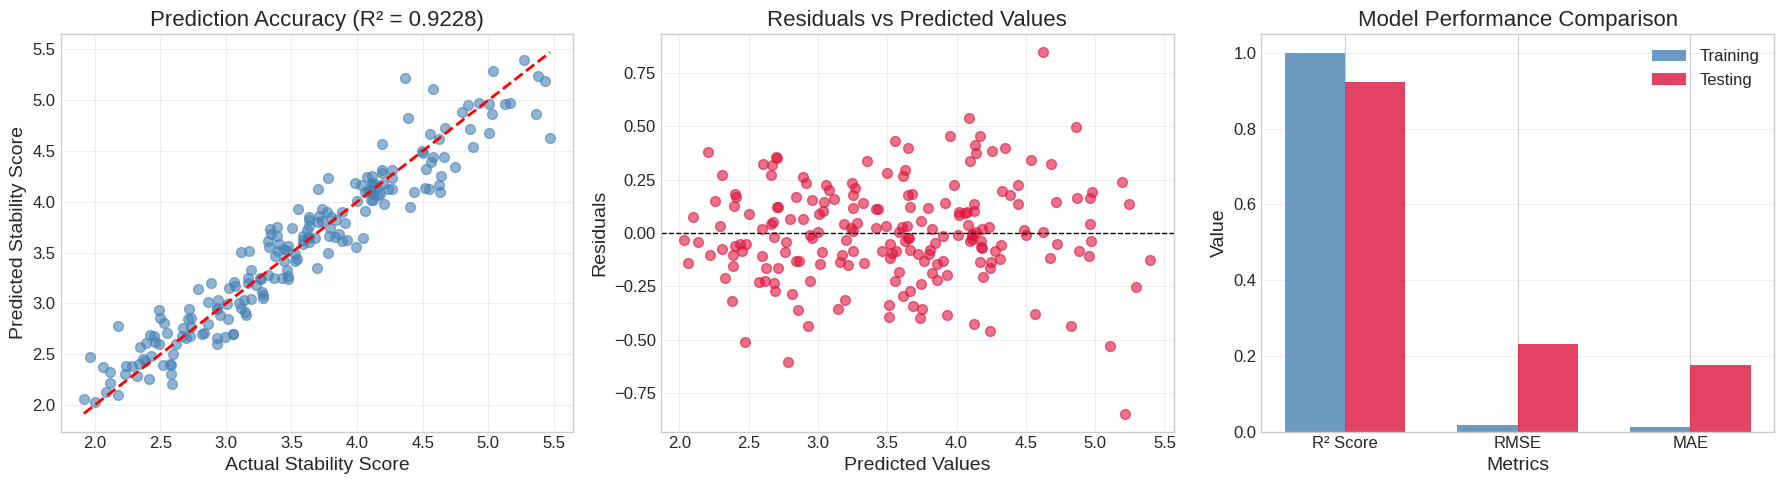

In [ ]:

print("MODEL EVALUATION")


# Generate predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate performance metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Display metrics in formatted table
print("\n" + "-"*50)
print("PERFORMANCE METRICS")
print("-"*50)
print(f"{'Metric':<15} {'Training':<12} {'Testing':<12}")
print("-"*50)
print(f"{'R² Score':<15} {train_r2:<12.4f} {test_r2:<12.4f}")
print(f"{'RMSE':<15} {train_rmse:<12.4f} {test_rmse:<12.4f}")
print(f"{'MAE':<15} {train_mae:<12.4f} {test_mae:<12.4f}")
print("-"*50)

# Check if target performance is achieved
if test_r2 >= 0.90:
    print("✓ Target achieved: R² > 0.90 on test data")
else:
    print(f"Target not achieved. Current R²: {test_r2:.4f}")

# Cross-validation with manual implementation
print("\nCross-validation analysis (5-fold):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled), 1):
    # Split data for this fold
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train model on fold
    fold_model = xgb.XGBRegressor(**model.get_params())
    fold_model.fit(X_fold_train, y_fold_train)

    # Evaluate on validation fold
    y_fold_pred = fold_model.predict(X_fold_val)
    fold_r2 = r2_score(y_fold_val, y_fold_pred)
    cv_scores.append(fold_r2)
    print(f"  Fold {fold}: R² = {fold_r2:.4f}")

cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)
print(f"\nCross-validation summary:")
print(f"  Mean R²: {cv_mean:.4f}")
print(f"  Std Dev: {cv_std:.4f}")

# Create performance visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual Values
axes[0].scatter(y_test, y_test_pred, alpha=0.6, s=50, color='steelblue')
max_val = max(y_test.max(), y_test_pred.max())
min_val = min(y_test.min(), y_test_pred.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Stability Score')
axes[0].set_ylabel('Predicted Stability Score')
axes[0].set_title(f'Prediction Accuracy (R² = {test_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Analysis
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, s=50, color='crimson')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].grid(True, alpha=0.3)

# Plot 3: Performance Metrics Comparison
metrics = ['R² Score', 'RMSE', 'MAE']
train_values = [train_r2, train_rmse, train_mae]
test_values = [test_r2, test_rmse, test_mae]

x = np.arange(len(metrics))
width = 0.35
axes[2].bar(x - width/2, train_values, width, label='Training', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, test_values, width, label='Testing', color='crimson', alpha=0.8)
axes[2].set_xlabel('Metrics')
axes[2].set_ylabel('Value')
axes[2].set_title('Model Performance Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

MODEL EXPLAINABILITY AND FEATURE IMPORTANCE


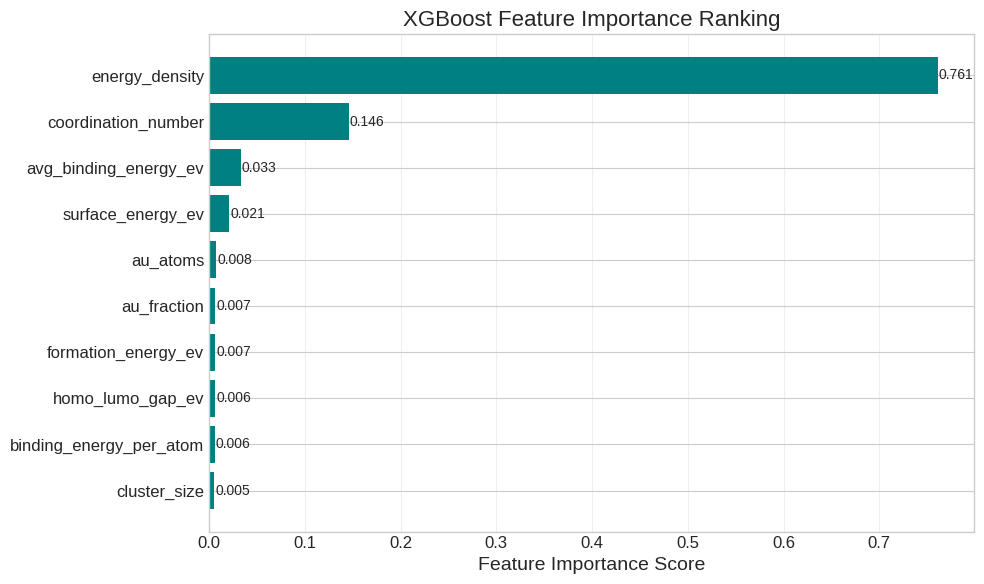


Top 5 Most Important Features for Stability Prediction:
--------------------------------------------------
1. energy_density            | Importance: 0.761
   Interpretation: Structural or energetic contribution

2. coordination_number       | Importance: 0.146
   Interpretation: Atomic packing and neighbor interactions

3. avg_binding_energy_ev     | Importance: 0.033
   Interpretation: Energy contribution per atomic interaction

4. surface_energy_ev         | Importance: 0.021
   Interpretation: Surface energy and stability

5. au_atoms                  | Importance: 0.008
   Interpretation: Structural or energetic contribution



In [ ]:

print("MODEL EXPLAINABILITY AND FEATURE IMPORTANCE")


# Extract feature importance
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Create feature importance visualization
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='teal')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([selected_features[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance Score')
ax.set_title('XGBoost Feature Importance Ranking')
ax.grid(True, alpha=0.3, axis='x')

# Add importance values to bars
for i, (bar, imp) in enumerate(zip(bars, feature_importance[sorted_idx])):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

# Display top features and their interpretations
print("\nTop 5 Most Important Features for Stability Prediction:")
print("-"*50)

top_indices = np.argsort(feature_importance)[-5:][::-1]
for rank, idx in enumerate(top_indices, 1):
    feature = selected_features[idx]
    importance = feature_importance[idx]

    # Provide interpretation based on feature type
    if 'binding' in feature.lower():
        interpretation = "Energy contribution per atomic interaction"
    elif 'coordination' in feature.lower():
        interpretation = "Atomic packing and neighbor interactions"
    elif 'ratio' in feature.lower() or 'fraction' in feature.lower():
        interpretation = "Compositional balance between Au and Ag"
    elif 'gap' in feature.lower():
        interpretation = "Electronic structure and reactivity"
    elif 'surface' in feature.lower():
        interpretation = "Surface energy and stability"
    else:
        interpretation = "Structural or energetic contribution"

    print(f"{rank}. {feature:25s} | Importance: {importance:.3f}")
    print(f"   Interpretation: {interpretation}")
    print()